# Kapitel 6 - Klustring

## Faktafrågor

### 1. Vad är klustring för något? Ge några exempel på tillämpningsområden.

Klustring är en del av maskininlärning där modellen grupperar datapunkter/observationer efter vilka som liknar varandra, utan facit (oövervakat lärande). Exempel på tillämpningsområden är kundsegmentering (gruppera kunder med liknande beteende) och att gruppera liknande produkter eller musik.

### 2. Förklara översiktligt hur K-means fungerar. Använd figur 6.3 (sidan 238) och figur 6.4 (sidan 239) i din förklaring.

K-means betyder att man i förväg bestämmer antal grupper (k), och sen hittas medelvärdet (means) för varje grupp. Man börjar med k slumpmässiga mittpunkter, varje punkt går till närmaste mittpunkt, sen flyttas mittpunkterna till medelvärdet av sin grupp. Detta upprepas tills mittpunkterna slutar flytta sig.

## Resonemangfrågor

### 3. Hur kan man välja vilket antal kluster som ska användas för en K-means modell? Använd inertia, silhouette score och silhouette diagram i ditt svar.

Man testar olika antal kluster (k) och kollar på några saker för att välja bäst k. Inertia minskar alltid när k ökar, så man letar efter en "knäck" i grafen där den slutar minska mycket (elbow method). Silhouette score visar hur bra punkterna passar i sina kluster, högre är bättre, så man väljer gärna k med högst score. Silhouette diagram visar det uppdelat per kluster, så man kan se om klustren är balanserade. Man kollar på alla tre tillsammans, inte bara ett av dom.

### 4. Om du kollar på figur 6.10 på sidan 247, hur många kluster hade du valt och varför? Är det en "exakt vetenskap" att välja antalet kluster?

Jag hade valt 4 kluster, det är där grafen har sin "armbåge" (elbow), kurvan slutar minska mycket efter det. Det är inte en exakt vetenskap, det är mer en tumregel/uppskattning, man skulle kunna argumentera för 3 eller 5 också beroende på hur man tolkar grafen.

### 5. Hur tolkar man figur 6.13 på sidan 251?

Figuren visar silhouette diagram för k=3, 4, 5 och 6. Varje färgad "kniv" är ett kluster, bredden visar silhouette-värdet för punkterna i det klustret (bredare/mer åt höger är bättre). Den streckade röda linjen visar medelvärdet för alla punkter vid den k. Man vill helst ha ett k där medelvärdet ligger långt till höger (nära 1) och där alla kluster är ungefär lika stora/breda utan tunna svansar som drar ner mot 0. Det är ingen exakt vetenskap, man får väga ihop det med inertia och sunt förnuft också.

## Koduppgifter

### 7. Kodexempel med "housing.csv": förklara vad koden gör, diskutera kluster-designen, och testa olika antal kluster.

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25
   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       1
1         8.3014     37.86    -122.22       1
2         7.2574     37.85    -122.24       1
3         5.6431     37.85    -122.25       1
4         3.8462     37.85    -122.25       4


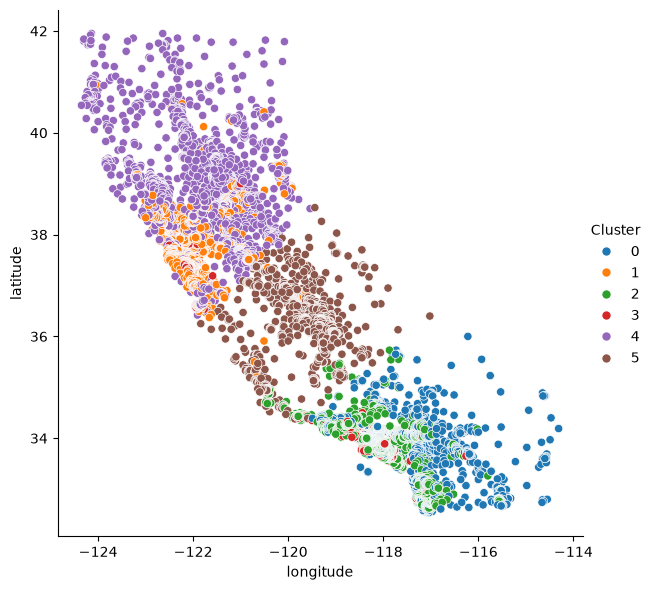

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

df_housing = pd.read_csv("data/housing.csv")
X = df_housing.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())

kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

print(X.head())

sns.relplot(
    x="longitude", y="latitude", hue="Cluster", data=X, height=6,
)

a) Koden läser in housing-datan, plockar ut inkomst och plats (latitude/longitude), och kör K-means med 6 kluster på dom. Sen plottas husen på en karta färgade efter vilket kluster dom hamnat i.

b) Jag hade velat veta saker som pristrend i området, vilken typ av hus/bostad dom föredrar, och kanske hur dom vill bli kontaktade.

c) Ett företag skulle kunna använda klustren för att rikta marknadsföring olika beroende på område och inkomstnivå, typ visa dyrare hus för höginkomstklustren.

d) Man skulle kunna testa olika antal kluster (elbow/silhouette som i tidigare frågor) för att se om 6 är ett bra val eller om nåt annat antal fungerar bättre.

### 9. Genomför en klustringanalys på "1980s classic hits with spotify data"-datasetet.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("data/1980sClassics.csv")
df.head()

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


#### Grundläggande info om datan

In [3]:
print(df.shape)
df.info()

(998, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    object 
 1   Artist            998 non-null    object 
 2   Duration          998 non-null    object 
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    

#### Välj variabler och skala datan

Vi plockar ut kolumnerna som beskriver hur låten låter. Skalar om dom innan K-means eftersom dom har olika skalor (typ volym vs dans-vänlighet).

In [4]:
features = ["Danceability", "Energy", "Loudness", "Speechiness",
            "Acousticness", "Instrumentalness", "Liveness", "Valence", "Tempo"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Testa olika antal kluster

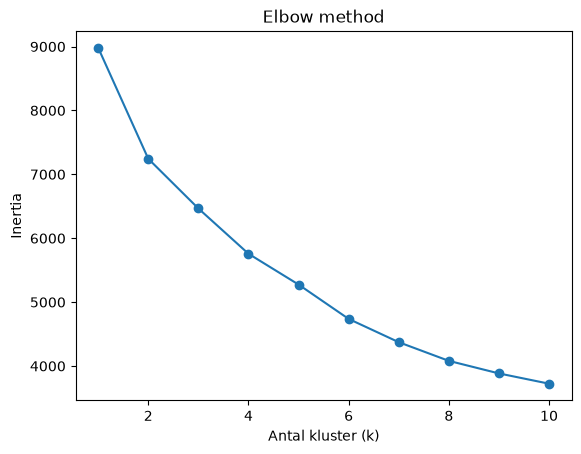

In [5]:
inertias = []
ks = range(1, 11)

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)  # sparar hur bra det gick för varje k

plt.plot(ks, inertias, marker="o")
plt.xlabel("Antal kluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.show()

Grafen planar ut runt 4-5, vi väljer k=4.

#### Kör klustringen och kolla resultatet

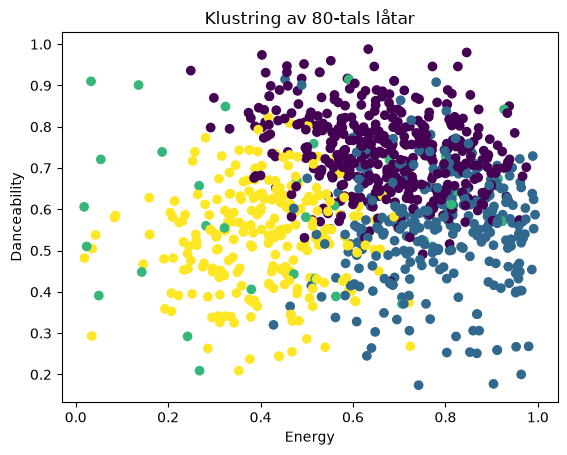

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
Cluster,,,,,,,,,
0,0.737064,0.676423,-8.992428,0.054056,0.152243,0.018216,0.122571,0.787333,115.373409
1,0.550783,0.782247,-6.093542,0.078899,0.130178,0.016894,0.280034,0.568155,131.783864
2,0.609943,0.468820,-12.866543,0.054880,0.507810,0.778714,0.130769,0.395400,129.559486
3,0.530700,0.405465,-11.476174,0.038710,0.501485,0.010367,0.159801,0.360247,116.110684


In [6]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)  # varje låt får en klustertillhörighet

plt.scatter(df["Energy"], df["Danceability"], c=df["Cluster"])
plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.title("Klustring av 80-tals låtar")
plt.show()

df.groupby("Cluster")[features].mean()  # medelvärde per kluster

Klustren verkar dela in låtarna ungefär såhär: kluster 0 är glada dansvänliga låtar (hög danceability och valence), kluster 1 är energiska/snabba låtar (hög energy och tempo), och kluster 2/3 är lugnare och tystare låtar (låg energy och loudness).